<img src="https://user-images.githubusercontent.com/7065401/75165824-badf4680-5701-11ea-9c5b-5475b0a33abf.png"
    style="width:300px; float: right; margin: 0 40px 40px 40px;"></img>

# Reading external data & Plotting (+TimeSeries)


[Ref Source](https://blockchain.info/charts/market-price)

![purple-divider](https://user-images.githubusercontent.com/7065401/52071927-c1cd7100-2562-11e9-908a-dde91ba14e59.png)

Hands on! 

In [143]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
%matplotlib inline

# Time Series Data - Btc-Market example

Pandas can easily read data stored in different file formats like CSV, JSON, XML or even Excel. Parsing always involves specifying the correct structure, encoding and other details. The `read_csv` method reads CSV files and accepts many parameters.

## Import csv data

In [144]:
btc = pd.read_csv("data/btc-market-price.csv")
btc

,2017-04-02 00:00:00,1099.169125
0,2017-04-03 00:00:00,1141.813000
1,2017-04-04 00:00:00,1141.600363
2,2017-04-05 00:00:00,1133.079314
3,2017-04-06 00:00:00,1196.307937
4,2017-04-07 00:00:00,1190.454250
...,...,...
359,2018-03-28 00:00:00,7960.380000
360,2018-03-29 00:00:00,7172.280000
361,2018-03-30 00:00:00,6882.531667
362,2018-03-31 00:00:00,6935.480000


The CSV file we're reading has only two columns: `timestamp` and `price`. It doesn't have a header, it contains whitespaces and has values separated by commas. pandas automatically assigned the first row of data as headers, which is incorrect. We can overwrite this behavior with the `header` parameter:

In [145]:
btc = pd.read_csv("data/btc-market-price.csv", header=None)
btc

,0,1
0,2017-04-02 00:00:00,1099.169125
1,2017-04-03 00:00:00,1141.813000
2,2017-04-04 00:00:00,1141.600363
3,2017-04-05 00:00:00,1133.079314
4,2017-04-06 00:00:00,1196.307937
...,...,...
360,2018-03-28 00:00:00,7960.380000
361,2018-03-29 00:00:00,7172.280000
362,2018-03-30 00:00:00,6882.531667
363,2018-03-31 00:00:00,6935.480000


In [146]:
btc.columns = ["Timestamp", "Price"]
btc

,Timestamp,Price
0,2017-04-02 00:00:00,1099.169125
1,2017-04-03 00:00:00,1141.813000
2,2017-04-04 00:00:00,1141.600363
3,2017-04-05 00:00:00,1133.079314
4,2017-04-06 00:00:00,1196.307937
...,...,...
360,2018-03-28 00:00:00,7960.380000
361,2018-03-29 00:00:00,7172.280000
362,2018-03-30 00:00:00,6882.531667
363,2018-03-31 00:00:00,6935.480000


## Dealing time data
The type of the `Price` column was correctly interpreted as `float`, but the `Timestamp` was interpreted as a regular string (`object` in pandas notation):

Timestamp     object
Price        float64
dtype: object


<Axes: >

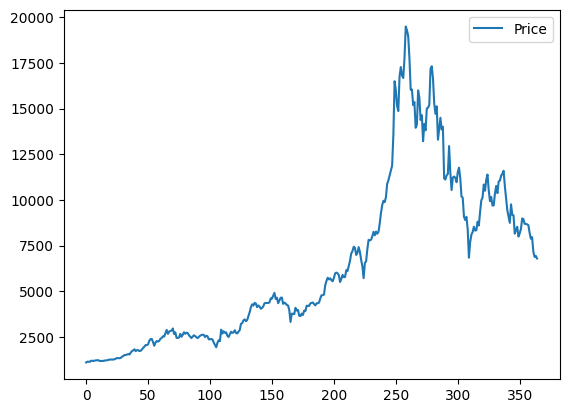

In [147]:
print(btc.dtypes)
btc.plot()
# x axis : btc - index
# y axis : btc data (only number data)

We can perform a vectorized operation to parse all the Timestamp values as `Datetime` objects:

In [148]:
btc["Timestamp"] = pd.to_datetime(btc["Timestamp"])
print(print(btc.dtypes))
btc

Timestamp    datetime64[ns]
Price               float64
dtype: object
None


,Timestamp,Price
0,2017-04-02,1099.169125
1,2017-04-03,1141.813000
2,2017-04-04,1141.600363
3,2017-04-05,1133.079314
4,2017-04-06,1196.307937
...,...,...
360,2018-03-28,7960.380000
361,2018-03-29,7172.280000
362,2018-03-30,6882.531667
363,2018-03-31,6935.480000


<Axes: >

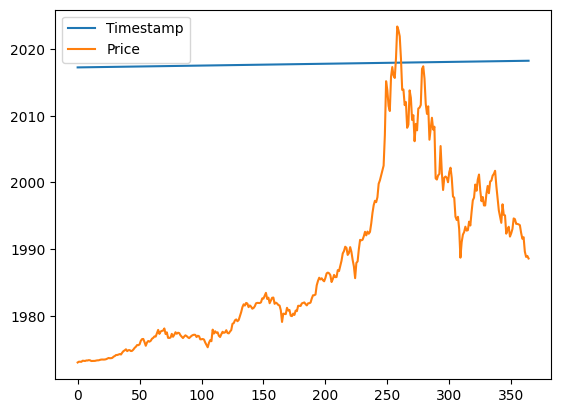

In [149]:
btc.plot()

### Plotting using matplotlib pyplot

Behind the scenes, it's using `matplotlib.pyplot`'s interface. We can create a similar plot with the `plt.plot()` function:

`plt.plot()` accepts many parameters, but the first two ones are the most important ones: the values for the `X` and `Y` axes. Another example:
Some of the arguments in `plt.figure` and `plt.plot` are available in the pandas' `plot` interface:

Text(0.5, 1.0, 'Bitcoin Price 2017-2018')

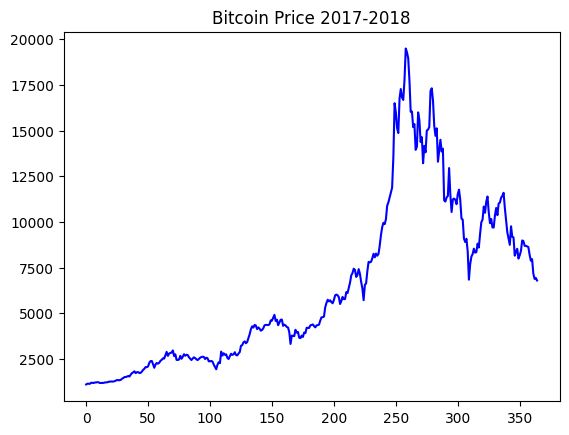

In [150]:
plt.plot(btc.index, btc["Price"], c="b")
plt.title("Bitcoin Price 2017-2018")

### Make timeseries data to be index before plotting!
The timestamp looks a lot like the index of this `DataFrame`: `date > price`. We can change the autoincremental ID generated by pandas and use the `Timestamp DS` column as the Index:

In [151]:
btc = btc.set_index("Timestamp")

<Axes: xlabel='Timestamp'>

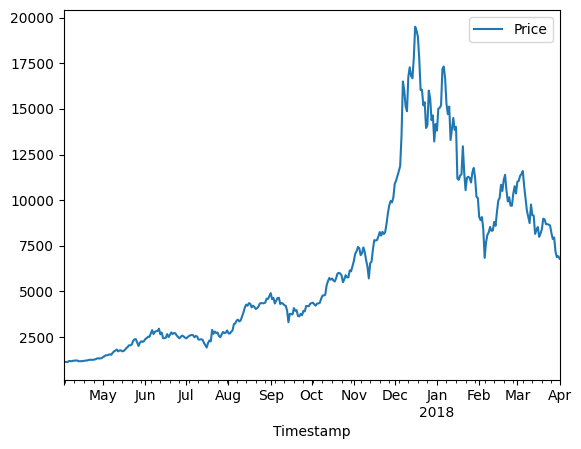

In [152]:
btc.plot()

<Axes: title={'center': 'Bitcoin Price 2017-2018'}, xlabel='Timestamp'>

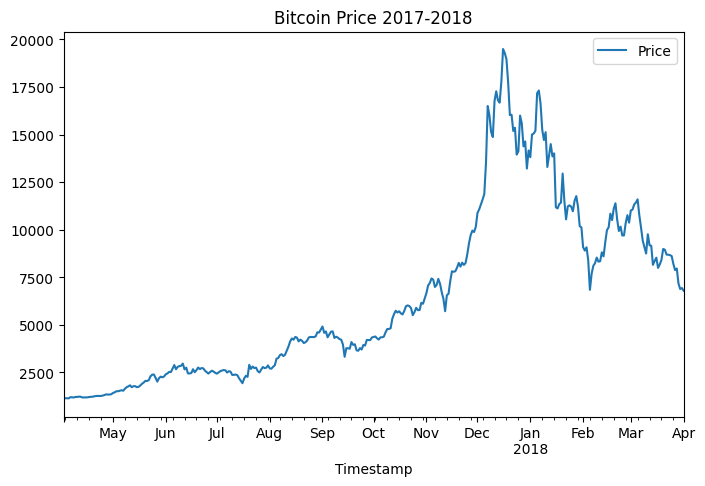

In [153]:
btc.plot(figsize=(8, 5), title="Bitcoin Price 2017-2018")

---

## Summary - Putting everything together

And now, we've finally arrived to the final, desired version of the `DataFrame` parsed from our CSV file. The steps were:

In [154]:
btc = pd.read_csv("data/btc-market-price.csv", header=None)
btc.columns = ["Timestamp", "Price"]
btc["Timestamp"] = pd.to_datetime(btc["Timestamp"])
btc.set_index("Timestamp", inplace=True)
btc

,Price
Timestamp,
2017-04-02,1099.169125
2017-04-03,1141.813000
2017-04-04,1141.600363
2017-04-05,1133.079314
2017-04-06,1196.307937
...,...
2018-03-28,7960.380000
2018-03-29,7172.280000
2018-03-30,6882.531667


### One code call?
**There should be a better way**. And there is 😎. And there usually is, explicitly with all these repetitive tasks with pandas.

The `read_csv` function is extremely powerful and you can specify many more parameters at import time. We can achive the same results with only one line by doing:

In [155]:
btc = pd.read_csv(
    "data/btc-market-price.csv",
    header=None,
    names=["Timestamp", "Price"],
    index_col=0,
    parse_dates=True,
)
btc

,Price
Timestamp,
2017-04-02,1099.169125
2017-04-03,1141.813000
2017-04-04,1141.600363
2017-04-05,1133.079314
2017-04-06,1196.307937
...,...
2018-03-28,7960.380000
2018-03-29,7172.280000
2018-03-30,6882.531667


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

# More challenging parsing - Eth-Price

To demonstrate plotting two columns together, we'll try to add Ether prices to our `df` DataFrame. The ETH prices data can be found in the `data/eth-price.csv` file. The problem is that it seems like that CSV file was created by someone who really hated programmers. Take a look at it and see how ugly it looks like. We'll still use `pandas` to parse it.

In [156]:
eth = pd.read_csv("data/eth-price.csv")
eth

,Date(UTC),UnixTimeStamp,Value
0,4/2/2017,1491091200,48.55
1,4/3/2017,1491177600,44.13
2,4/4/2017,1491264000,44.43
3,4/5/2017,1491350400,44.90
4,4/6/2017,1491436800,43.23
...,...,...,...
357,3/28/2018,1522195200,445.93
358,3/29/2018,1522281600,383.90
359,3/30/2018,1522368000,393.82
360,3/31/2018,1522454400,394.07


In [157]:
eth.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 362 entries, 0 to 361
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date(UTC)      362 non-null    object 
 1   UnixTimeStamp  362 non-null    int64  
 2   Value          362 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 8.6+ KB


As you can see, it has a `Value` column (which represents the price), a `Date(UTC)` one that has a string representing dates and also a `UnixTimeStamp` date represeting the datetime in unix timestamp format. 

The header is read automatically, let's try to parse dates with the CSV Reader:

In [158]:
temp = pd.read_csv("data/eth-price.csv", parse_dates=["Date(UTC)", "UnixTimeStamp"])
print(temp.dtypes)
temp.head()

Date(UTC)        datetime64[ns]
UnixTimeStamp            object
Value                   float64
dtype: object


/var/folders/0s/p6r6pj_15m5cg5q_gj8_xdjm0000gn/T/ipykernel_91801/2101458705.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  temp = pd.read_csv("data/eth-price.csv", parse_dates=["Date(UTC)", "UnixTimeStamp"])


,Date(UTC),UnixTimeStamp,Value
0,2017-04-02,1491091200,48.55
1,2017-04-03,1491177600,44.13
2,2017-04-04,1491264000,44.43
3,2017-04-05,1491350400,44.90
4,2017-04-06,1491436800,43.23


Seems like the `parse_dates` attribute didn't work very well. Let's try to see if Date(UTC) can be parsed at least

In [159]:
temp = pd.read_csv("data/eth-price.csv", parse_dates=["Date(UTC)"])
print(temp.dtypes)
temp.head()

Date(UTC)        datetime64[ns]
UnixTimeStamp             int64
Value                   float64
dtype: object


,Date(UTC),UnixTimeStamp,Value
0,2017-04-02,1491091200,48.55
1,2017-04-03,1491177600,44.13
2,2017-04-04,1491264000,44.43
3,2017-04-05,1491350400,44.90
4,2017-04-06,1491436800,43.23


And you will see it is working :)

Note that the `parse_dates=True` parameter will instruct pandas to parse the index of the `DataFrame`. If you want to parse any other column, you must explicitly pass the column position or name:

Then how can we convert UnixTimeStamp anyways?

We'll need to add a little bit more customization. Let's divide this problem and focus on the problem of "date parsing" first. The simplest option would be to use the `UnixTimeStamp` column. The `pandas` module has a `to_datetime` function that converts Unix timestamps to Datetime objects automatically:

In [160]:
eth = pd.read_csv("data/eth-price.csv")
eth["Date(UTC)"] = pd.to_datetime(eth["Date(UTC)"])
eth["UnixTimeStamp"] = pd.to_datetime(eth["UnixTimeStamp"], unit="s")
print(eth.info())
eth

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 362 entries, 0 to 361
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date(UTC)      362 non-null    datetime64[ns]
 1   UnixTimeStamp  362 non-null    datetime64[ns]
 2   Value          362 non-null    float64       
dtypes: datetime64[ns](2), float64(1)
memory usage: 8.6 KB
None


,Date(UTC),UnixTimeStamp,Value
0,2017-04-02,2017-04-02,48.55
1,2017-04-03,2017-04-03,44.13
2,2017-04-04,2017-04-04,44.43
3,2017-04-05,2017-04-05,44.90
4,2017-04-06,2017-04-06,43.23
...,...,...,...
357,2018-03-28,2018-03-28,445.93
358,2018-03-29,2018-03-29,383.90
359,2018-03-30,2018-03-30,393.82
360,2018-03-31,2018-03-31,394.07


<Axes: xlabel='Date(UTC)'>

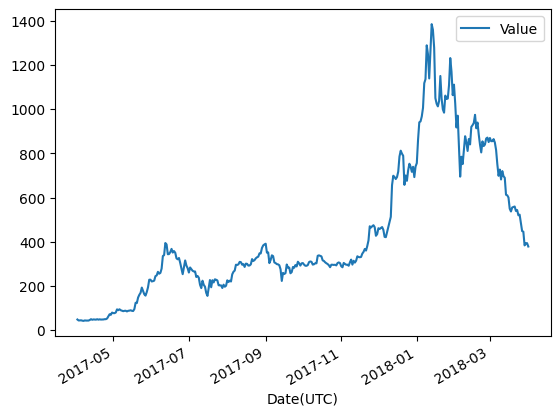

In [161]:
eth.set_index("Date(UTC)").iloc[:, [-1]].plot()

The problem is the precision of unix timestamps. To match both columns we'll need to use the same index and, our `df` containing Bitcoin prices, is "per day":

We could either, remove the precision of `UnixTimeStamp` or attempt to parse the `Date(UTC)`. Let's do String parsing of `Date(UTC)` for fun:

## Combining Two DataFrames

We can now combine both `DataFrame`s into one. Both have the same index, so aligning both prices will be easy. Let's first create an empty `DataFrame` and with the index from Bitcoin prices:

In [162]:
prices = pd.DataFrame(index=btc.index)
prices

""
Timestamp
2017-04-02
2017-04-03
2017-04-04
2017-04-05
2017-04-06
...
2018-03-28
2018-03-29
2018-03-30


And we can now just set columns from the other `DataFrame`s:

In [163]:
prices["Bitcoin"] = btc["Price"]
prices

,Bitcoin
Timestamp,
2017-04-02,1099.169125
2017-04-03,1141.813000
2017-04-04,1141.600363
2017-04-05,1133.079314
2017-04-06,1196.307937
...,...
2018-03-28,7960.380000
2018-03-29,7172.280000
2018-03-30,6882.531667


In [164]:
prices["Ether"] = eth["Value"]
prices  # not working why?

,Bitcoin,Ether
Timestamp,,
2017-04-02,1099.169125,NaN
2017-04-03,1141.813000,NaN
2017-04-04,1141.600363,NaN
2017-04-05,1133.079314,NaN
2017-04-06,1196.307937,NaN
...,...,...
2018-03-28,7960.380000,NaN
2018-03-29,7172.280000,NaN
2018-03-30,6882.531667,NaN


In [165]:
eth

,Date(UTC),UnixTimeStamp,Value
0,2017-04-02,2017-04-02,48.55
1,2017-04-03,2017-04-03,44.13
2,2017-04-04,2017-04-04,44.43
3,2017-04-05,2017-04-05,44.90
4,2017-04-06,2017-04-06,43.23
...,...,...,...
357,2018-03-28,2018-03-28,445.93
358,2018-03-29,2018-03-29,383.90
359,2018-03-30,2018-03-30,393.82
360,2018-03-31,2018-03-31,394.07


In [166]:
eth = eth.set_index("Date(UTC)")
eth

,UnixTimeStamp,Value
Date(UTC),,
2017-04-02,2017-04-02,48.55
2017-04-03,2017-04-03,44.13
2017-04-04,2017-04-04,44.43
2017-04-05,2017-04-05,44.90
2017-04-06,2017-04-06,43.23
...,...,...
2018-03-28,2018-03-28,445.93
2018-03-29,2018-03-29,383.90
2018-03-30,2018-03-30,393.82


In [167]:
prices["Ether"] = eth["Value"]
prices

,Bitcoin,Ether
Timestamp,,
2017-04-02,1099.169125,48.55
2017-04-03,1141.813000,44.13
2017-04-04,1141.600363,44.43
2017-04-05,1133.079314,44.90
2017-04-06,1196.307937,43.23
...,...,...
2018-03-28,7960.380000,445.93
2018-03-29,7172.280000,383.90
2018-03-30,6882.531667,393.82


<Axes: xlabel='Timestamp'>

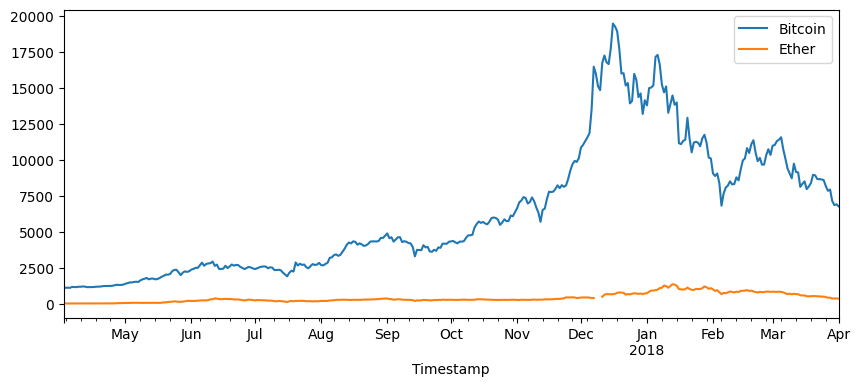

In [168]:
prices.plot(figsize=(10, 4))  # We can now try plotting both values:

🤔seems like there's a tiny gap between Dec 2017 and Jan 2018. Let's zoom in there:

<Axes: xlabel='Timestamp'>

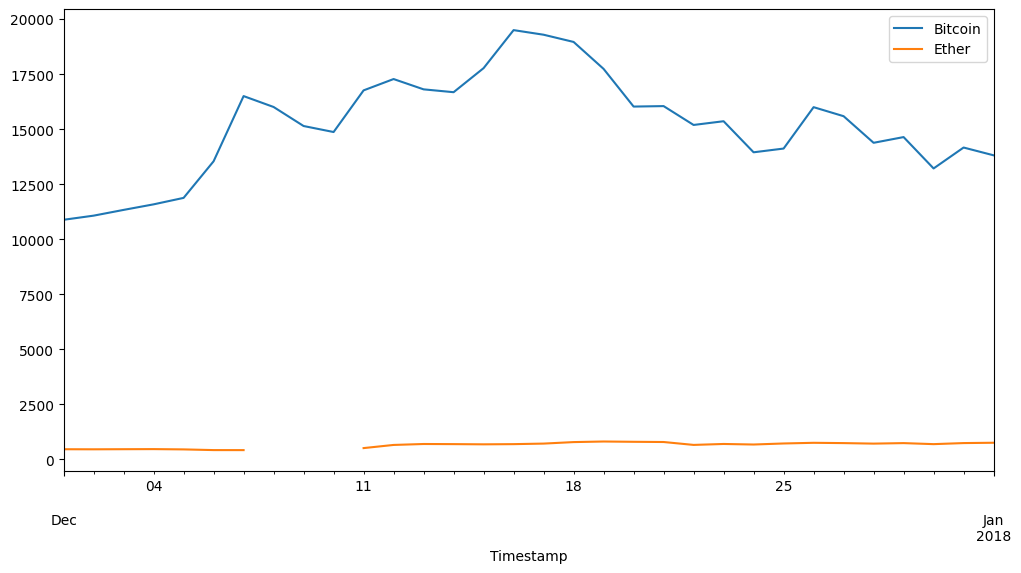

In [169]:
prices.loc["2017-12-01":"2018-01-01"].plot(figsize=(12, 6))

Oh no, missing data 😱. We'll learn how to deal with that later 😉.

Btw, did you note that fancy indexing `'2017-12-01':'2018-01-01'` 😏. That's pandas power 💪. We'll learn how to deal with TimeSeries later too.

# More Real Examples

In [170]:
df = pd.read_csv("data/btc-eth-prices-outliers.csv", index_col=0, parse_dates=True)
df

,Bitcoin,Ether
Timestamp,,
2017-04-02,1099.169125,48.55
2017-04-03,1141.813000,44.13
2017-04-04,1141.600363,44.43
2017-04-05,1133.079314,44.90
2017-04-06,1196.307937,43.23
...,...,...
2018-03-28,7960.380000,445.93
2018-03-29,7172.280000,383.90
2018-03-30,6882.531667,393.82


And now we can run a simple visualization:

<Axes: xlabel='Timestamp'>

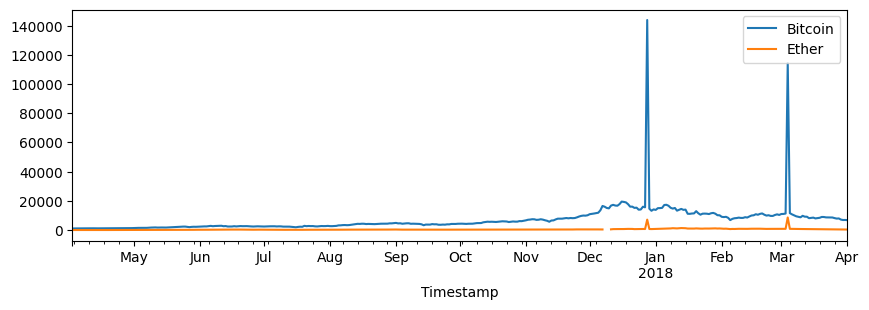

In [171]:
df.plot(figsize=(10, 3))

There are clearly some invalid values, both ETH and BTC have huge spikes. On top of that, there seems to be some data missing in Ether between December 2017 and and January 2018:

<Axes: xlabel='Timestamp'>

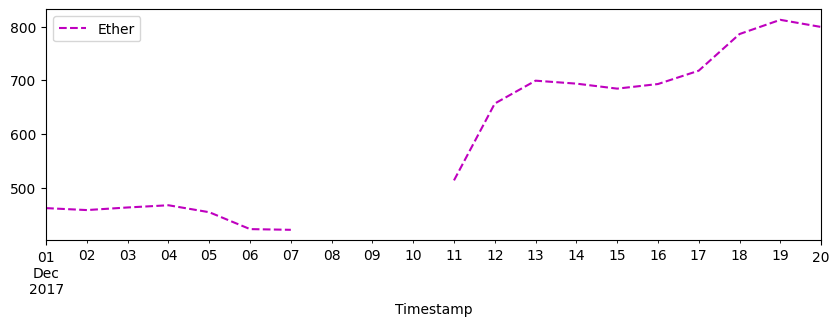

In [172]:
df.loc["2017-12-01":"2017-12-20"].plot(y="Ether", c="m", ls="dashed", figsize=(10, 3))

Are those null values?

In [173]:
df_na = df.loc["2017-12":"2017-12-15"]
df_na["Ether"].isna().any()

np.True_

When? what periods of time?

In [174]:
mask = df_na["Ether"].isna()
df_na[mask]

,Bitcoin,Ether
Timestamp,,
2017-12-08,16007.436667,NaN
2017-12-09,15142.834152,NaN
2017-12-10,14869.805000,NaN


Let's add a little bit more context:

In [175]:
df.loc["2017-12-06":"2017-12-12"]

,Bitcoin,Ether
Timestamp,,
2017-12-06,13540.980000,422.48
2017-12-07,16501.971667,421.15
2017-12-08,16007.436667,NaN
2017-12-09,15142.834152,NaN
2017-12-10,14869.805000,NaN
2017-12-11,16762.116667,513.29
2017-12-12,17276.393333,656.52


We now need to decide what we'll do with the missing values. Drop them? fill them? If we decide to fill them, what will be use as fill value? For example: we can use the previous value and just assume the price stayed the same.

In [176]:
df.loc["2017-12-06":"2017-12-12"].bfill()

,Bitcoin,Ether
Timestamp,,
2017-12-06,13540.980000,422.48
2017-12-07,16501.971667,421.15
2017-12-08,16007.436667,513.29
2017-12-09,15142.834152,513.29
2017-12-10,14869.805000,513.29
2017-12-11,16762.116667,513.29
2017-12-12,17276.393333,656.52


<Axes: xlabel='Timestamp'>

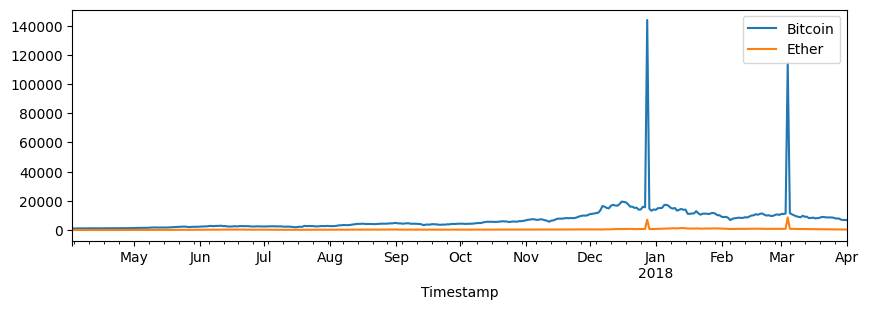

In [177]:
df.bfill(inplace=True)
df.plot(figsize=(10, 3))

Much better. We now need to fix the huge spikes. The first step is identifying them. How can we do it? The simple answer is of course visually. They seem to be located in the last 10 days of Dec 2017 and first of March 2018:

<Axes: xlabel='Timestamp'>

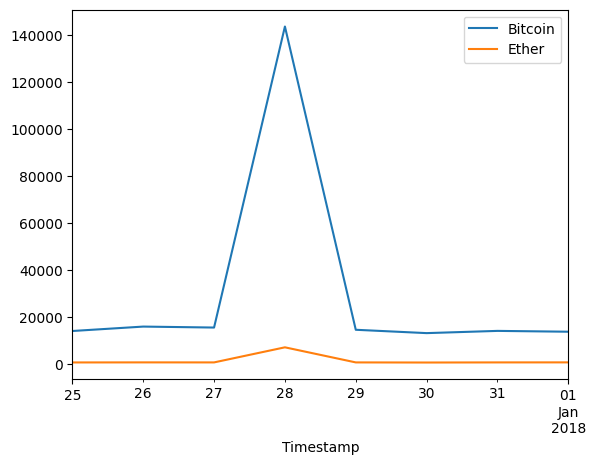

In [178]:
df["2017-12-25":"2018-01-01"].plot()

Apparently, they're located in '2017-12-28' and '2018-03-04':

In [179]:
df["2017-12-27":"2018-03-05"]

,Bitcoin,Ether
Timestamp,,
2017-12-27,15589.321667,739.94
2017-12-28,143805.816667,7166.90
2017-12-29,14640.140000,739.60
2017-12-30,13215.574000,692.99
2017-12-31,14165.575000,741.13
...,...,...
2018-03-01,11009.381667,869.87
2018-03-02,11055.815000,855.60
2018-03-03,11326.948333,855.65


In [180]:
df_cleaned = df.drop(pd.to_datetime(["2017-12-28", "2018-03-04"]))

<Axes: xlabel='Timestamp'>

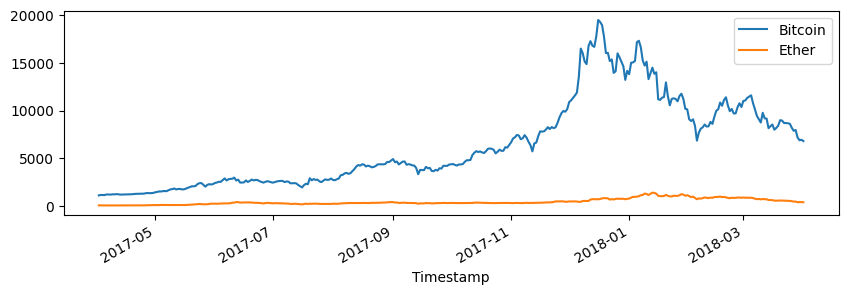

In [181]:
df_cleaned.plot(figsize=(10, 3))

Now it looks much better. Our data seems to be clean.

## Cleaning Analysis 

Visualizations helps make sense of the data and let us judge if our analysis and work is on the right track. But we need a more powerful method to handle our data. That's what we call "analysis". We'll use _analytical_ methods to identify these outliers or these skewed values.

### Central Tendency

We'll use a set of common indicators of to measure central tendency and identify these outliers:

The `mean` is probably the most common and popular one. The problem is that it's really sensitive to outliers. The mean of our dataset with invalid values is:

In [182]:
df.mean()

Bitcoin    6996.004022
Ether       469.609068
dtype: float64

Both values seem too high. That's because the outliers are skewing with the mean:

In [183]:
df_cleaned.mean()

Bitcoin    6323.509186
Ether       428.628402
dtype: float64

In [184]:
df.median()

Bitcoin    4594.98785
Ether       309.49000
dtype: float64

`mode`. It doesn't make much sense to measure the mode, as we have continuous values. But you can do it just with `df.mode()`.

### Visualizing Distribution

Now we can use a few of the charts that we saw before + seaborn to visualize the distribution of our values. In particular, we're interested in **histograms**:

Text(0.5, 1.0, 'bitcoin histogram')

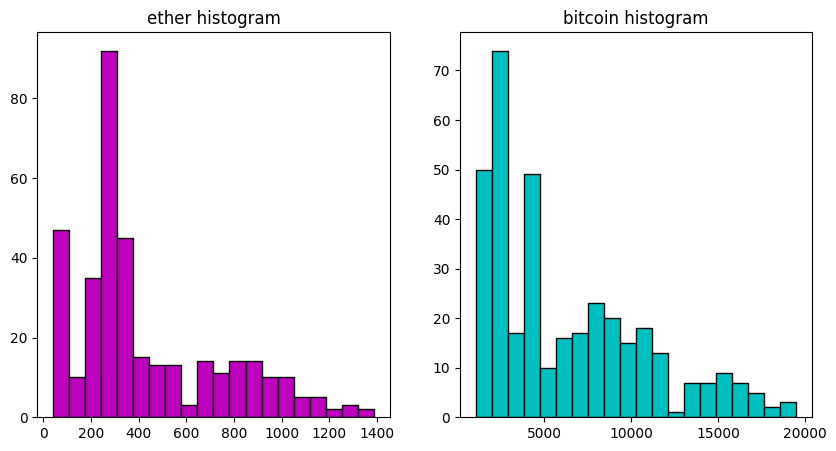

In [185]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].hist(df_cleaned.Ether, bins=20, color="m", edgecolor="black")
axes[0].set_title("ether histogram")
axes[1].hist(df_cleaned.Bitcoin, bins=20, color="c", edgecolor="black")
axes[1].set_title("bitcoin histogram")

<Axes: xlabel='Ether', ylabel='Count'>

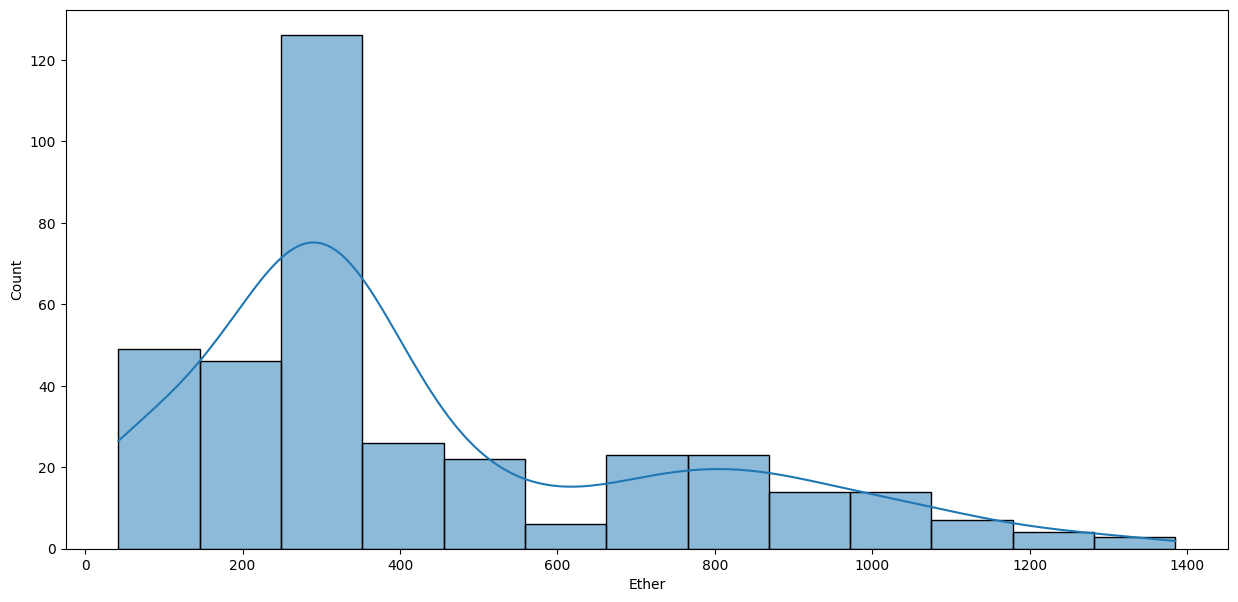

In [186]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(15, 7))
sns.histplot(df_cleaned["Ether"], kde=True, ax=ax)

<Axes: xlabel='Bitcoin', ylabel='Count'>

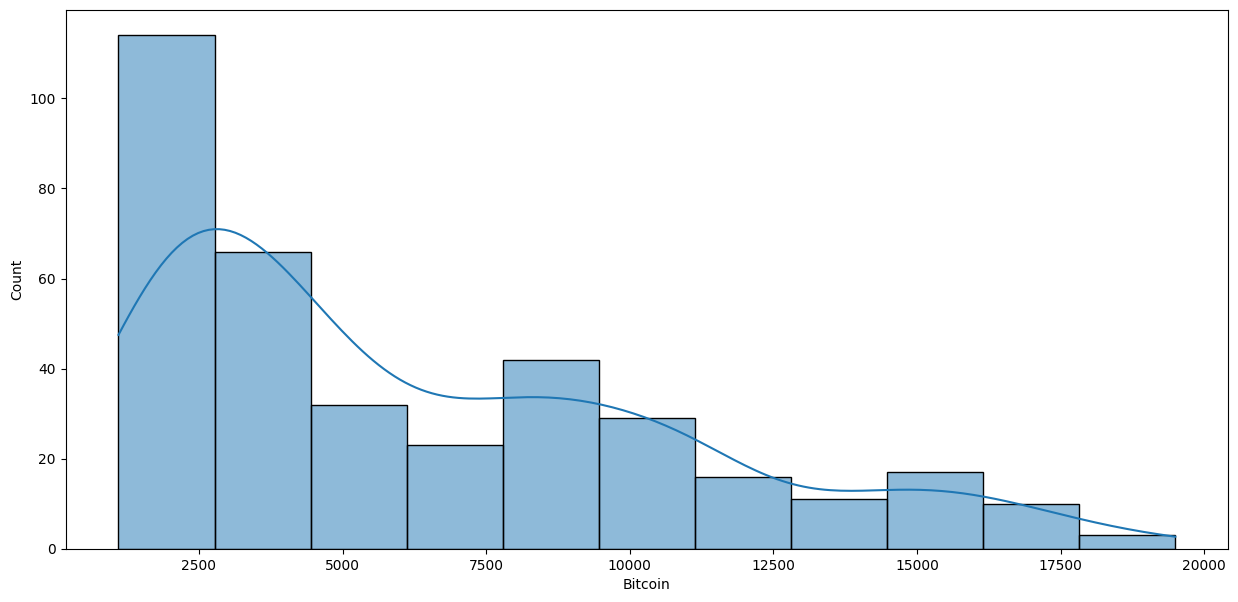

In [187]:
fig, ax = plt.subplots(figsize=(15, 7))
sns.histplot(df_cleaned["Bitcoin"], kde=True, ax=ax)

<Axes: xlabel='Ether', ylabel='Density'>

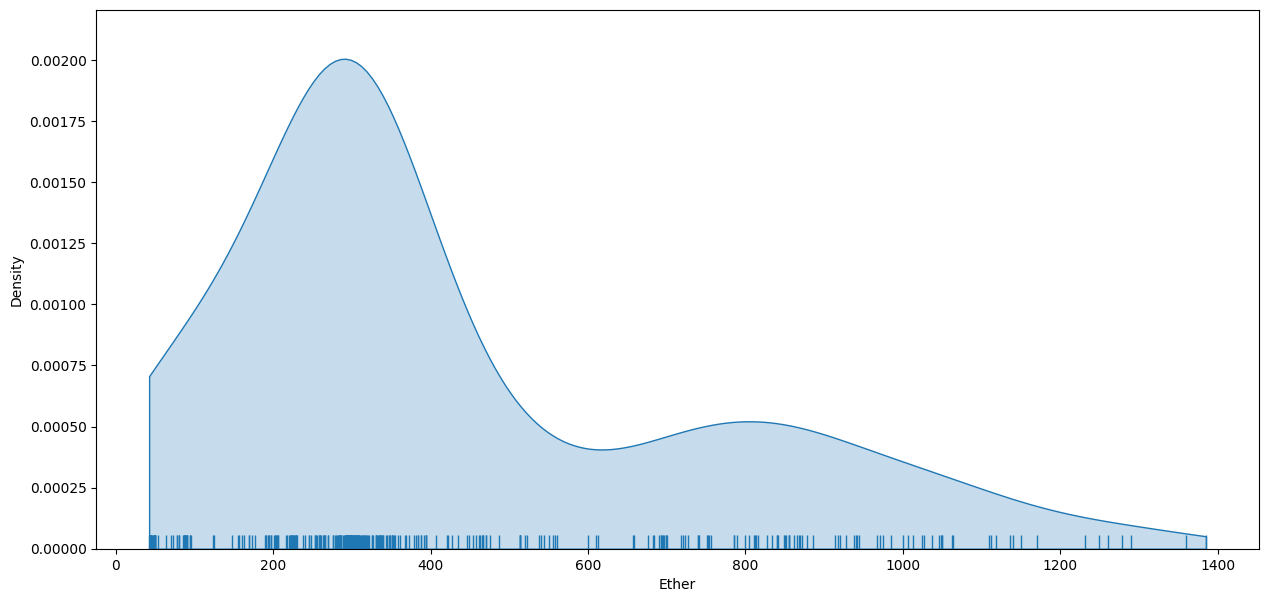

In [188]:
fig, ax = plt.subplots(figsize=(15, 7))
sns.kdeplot(df_cleaned["Ether"], fill=True, cut=0, ax=ax)
sns.rugplot(df_cleaned["Ether"], ax=ax)

We can also visualize a cumulative plot of our distribution:

<Axes: xlabel='Bitcoin', ylabel='Density'>

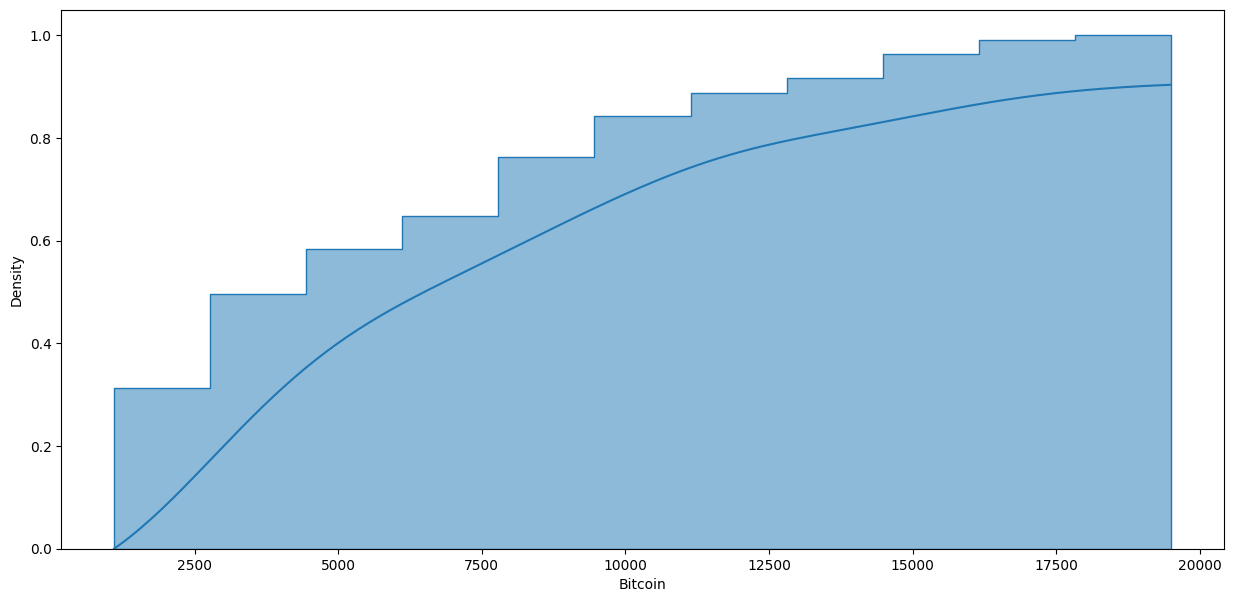

In [199]:
fig, ax = plt.subplots(figsize=(15, 7))
sns.histplot(
    df_cleaned["Bitcoin"],
    ax=ax,
    stat="density",
    cumulative=True,
    kde=True,
    element="step",
    fill=True,
)

This plot shows how many samples fall behind a certain value. We can increase the number of bins in order to have more detail:

Text(0, 0.5, 'Cumulative Density')

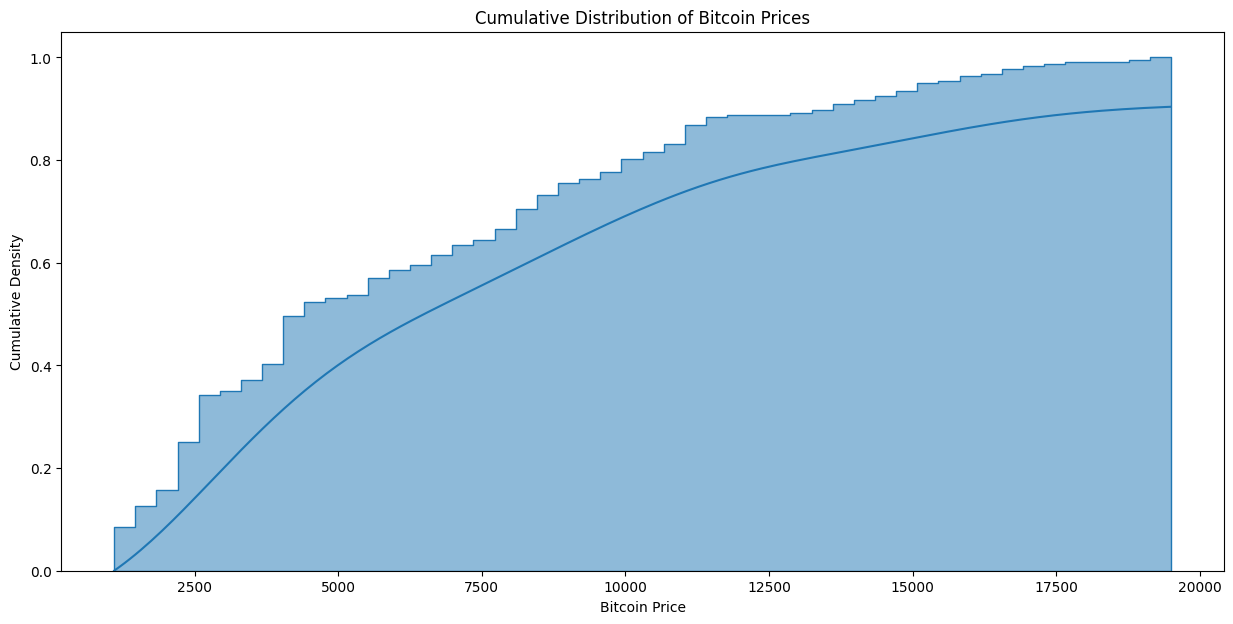

In [201]:
fig, ax = plt.subplots(figsize=(15, 7))

# Plot cumulative histogram with KDE
sns.histplot(
    df_cleaned["Bitcoin"],
    bins=50,
    ax=ax,
    stat="density",               # Normalize the histogram to match KDE scale
    cumulative=True,              # Enable cumulative histogram
    kde=True,                     # Overlay a KDE curve
    kde_kws={'cumulative': True},  # Make the KDE cumulative as well
    element="step",               # Use step lines instead of bars
    fill=True                    # Fill the area under the histogram
)

# Set plot titles and labels
ax.set_title("Cumulative Distribution of Bitcoin Prices")
ax.set_xlabel("Bitcoin Price")
ax.set_ylabel("Cumulative Density")

### Visualizing bivariate distributions

The most common way to observe a bivariate distribution is a scatterplot, the `jointplot` will also include the distribution of the variables:

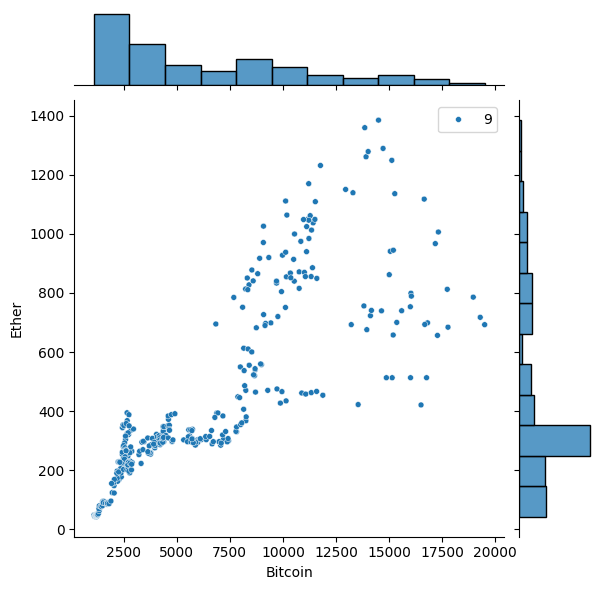

In [202]:
sns.jointplot(x="Bitcoin", y="Ether", data=df_cleaned, size=9)

If you want only a scatter plot, you can use the `regplot` method, that also fits a linear regression model in the plot:

<Axes: xlabel='Bitcoin', ylabel='Ether'>

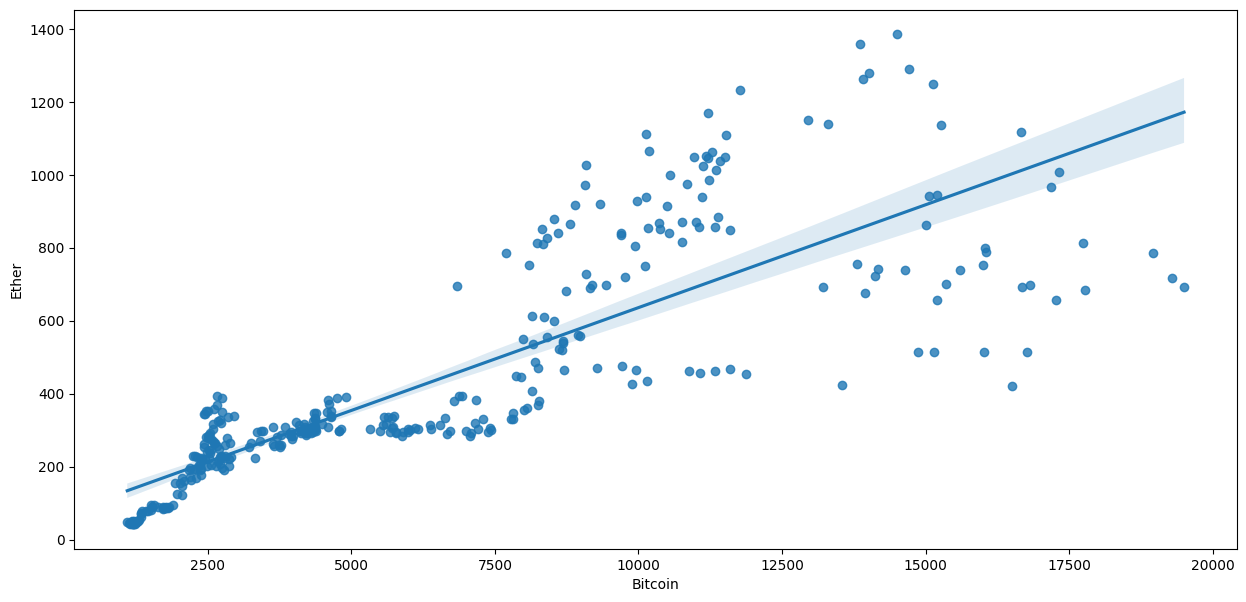

In [203]:
fig, ax = plt.subplots(figsize=(15, 7))
sns.regplot(x="Bitcoin", y="Ether", data=df_cleaned, ax=ax)

### Quantiles, quartiles and percentiles

In [204]:
df_cleaned["Bitcoin"].quantile(0.2)

np.float64(2438.8627342857144)

Text(0, 0.5, 'Cumulative Density')

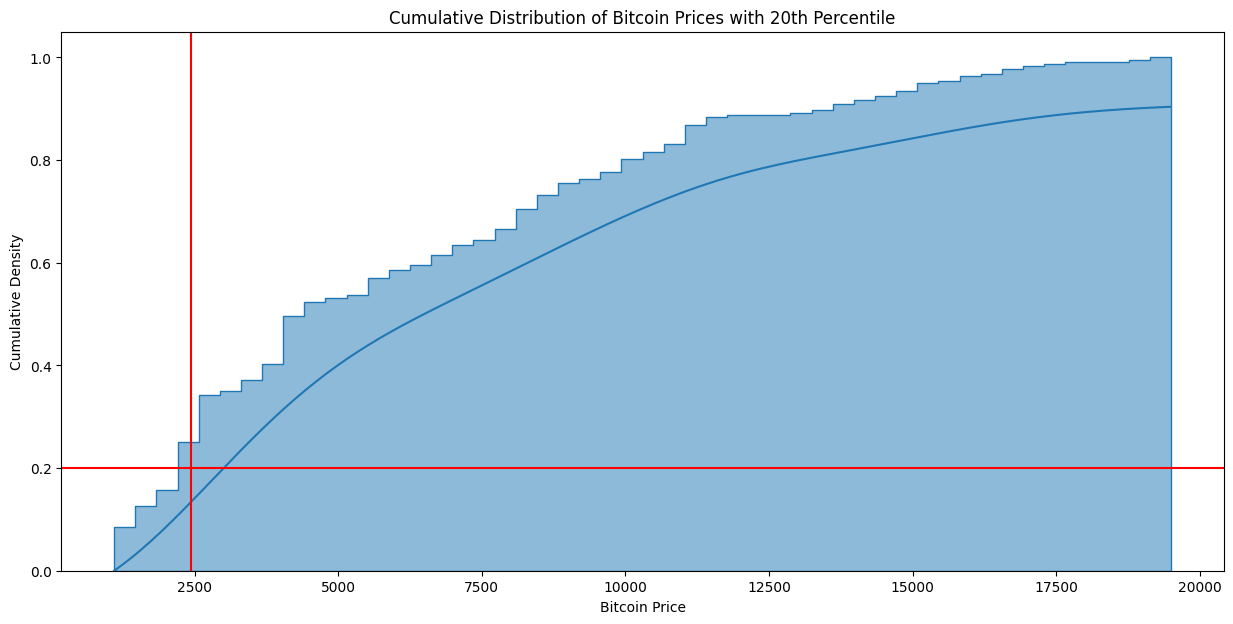

In [206]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(15, 7))

# Plot cumulative histogram with KDE (modern version)
sns.histplot(
    df_cleaned["Bitcoin"],
    bins=50,
    ax=ax,
    stat="density",                   # Normalize histogram to match KDE
    cumulative=True,                  # Make it cumulative
    kde=True,                         # Add KDE curve
    kde_kws={"cumulative": True},     # Make KDE cumulative
    element="step",                   # Step-style lines
    fill=True                         # Fill the area under histogram
)

# Draw a horizontal line at cumulative density = 0.2
ax.axhline(0.2, color="red")

# Draw a vertical line at the 20th percentile value
ax.axvline(df_cleaned["Bitcoin"].quantile(0.2), color="red")

# Optional: add titles and labels
ax.set_title("Cumulative Distribution of Bitcoin Prices with 20th Percentile")
ax.set_xlabel("Bitcoin Price")
ax.set_ylabel("Cumulative Density")

In [208]:
print("Median:", df_cleaned["Bitcoin"].quantile(0.5).round(2))

Median: 4580.39


Text(0, 0.5, 'Cumulative Density')

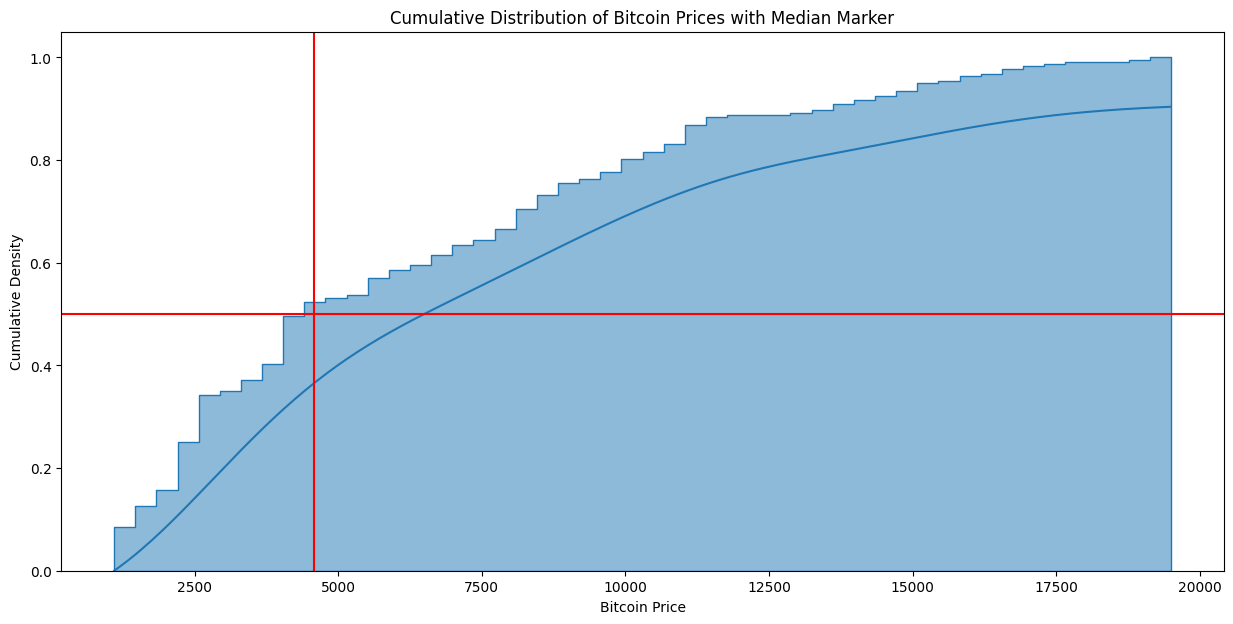

In [210]:

# Create a figure and axis
fig, ax = plt.subplots(figsize=(15, 7))

# Plot cumulative histogram with KDE (modern Seaborn)
sns.histplot(
    df_cleaned["Bitcoin"],
    ax=ax,
    bins=50,
    stat="density",                    # Normalize to make compatible with KDE
    cumulative=True,                   # Cumulative histogram
    kde=True,                          # Add KDE curve
    kde_kws={"cumulative": True},      # Make KDE cumulative too
    element="step",                    # Use step-style for clarity
    fill=True                          # Fill the area under the histogram
)

# Draw horizontal and vertical lines at the 50th percentile (median)
ax.axhline(0.5, color="red")  # Y = 0.5
ax.axvline(df_cleaned["Bitcoin"].quantile(0.5), color="red")  # Median X-value

# Add titles and labels
ax.set_title("Cumulative Distribution of Bitcoin Prices with Median Marker")
ax.set_xlabel("Bitcoin Price")
ax.set_ylabel("Cumulative Density")

Quantile `0.25` == Percentile `25%` == Quartile `1st`

## Dispersion

We'll use a few methods to measure dispersion in our dataset, most of them well known:

* Range
* Variance and Standard Deviation
* IQR

#### Range

`Range` is fairly simple to understand, it's just the max - min values:

Range is **really** sensitive to outliers. As you can see, the range value is extremely high (might indicate the presence of outliers / invalid values).

The range of `df_cleaned` value makes a lot more sense. We know that Bitcoin had a high in about 20k, and it was around 900 when we started measuring. It makes more sense now.

In [213]:
print((df["Bitcoin"].max() - df["Bitcoin"].min()).round(2))
print((df_cleaned["Bitcoin"].max() - df_cleaned["Bitcoin"].min()).round(2))

142706.65
18399.51


#### variance and standard deviation

In [216]:
print((df["Bitcoin"].std()).round(2))
print((df_cleaned["Bitcoin"].std()).round(2))

10186.59
4513.76


#### IQR

The [Interquartile range](https://en.wikipedia.org/wiki/Interquartile_range) is a good measure of "centered" dispersion, and is calculated as `Q3 - Q1` (3rd quartile - 1st quartile).

As you can see below, `IQR` is more robust than std or range, because it's not so sensitive to outliers.

In [219]:
iqr = df["Bitcoin"].quantile(0.75) - df["Bitcoin"].quantile(0.25)
iqr2 = df_cleaned["Bitcoin"].quantile(
    0.75) - df_cleaned["Bitcoin"].quantile(0.25)
print(iqr.round(2))
print(iqr2.round(2))

6597.49
6548.25


#### Analytical Analysis of invalid values

We can now use the measurements we've seen to analyze those values that seem invalid.

##### Using `std`: Z scores

We can now define those values that are a couple of Z scores above or below the mean (or the max/min value). Example:

In [220]:
upper_limit = df["Bitcoin"].mean() + 2 * df["Bitcoin"].std()
lower_limit = df["Bitcoin"].mean() - 2 * df["Bitcoin"].std()

In [228]:
print("Upper Limit: {:.2f}".format(upper_limit))
print("Lower Limit: {:.2f}".format(lower_limit))

Upper Limit: 27369.18
Lower Limit: -13377.17


Text(0, 0.5, 'Density')

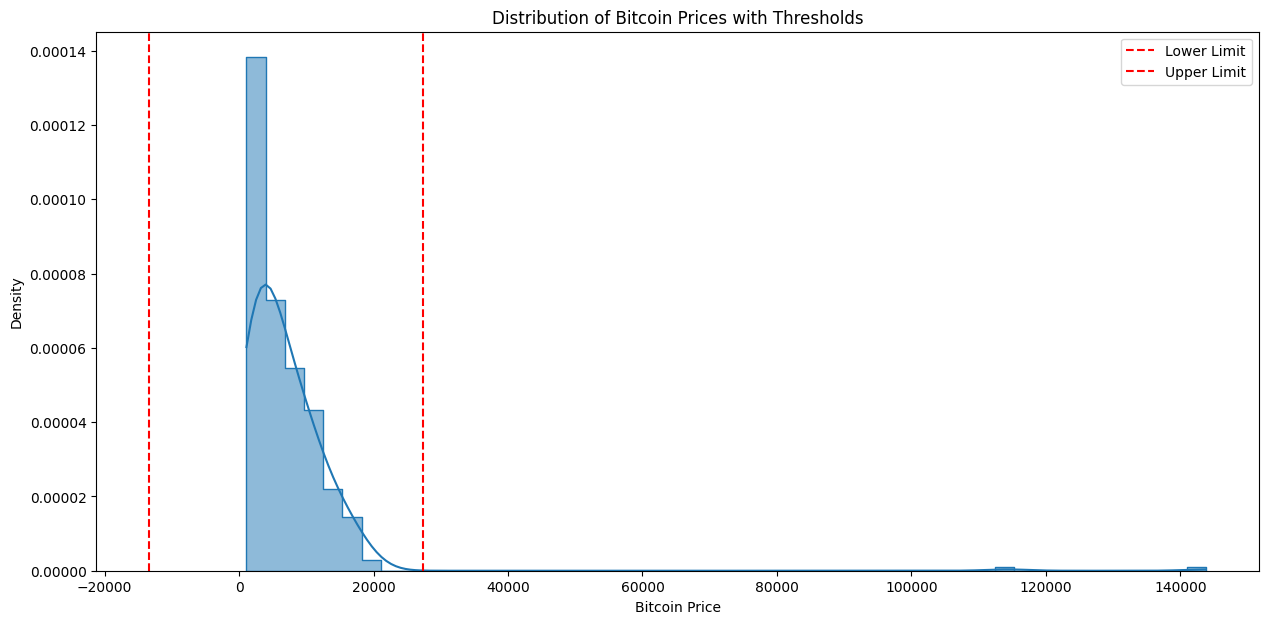

In [229]:

# Create a figure and axis
fig, ax = plt.subplots(figsize=(15, 7))

# Plot histogram with KDE overlay
sns.histplot(
    df["Bitcoin"],
    ax=ax,
    bins=50,
    stat="density",
    kde=True,
    element="step",
    fill=True
)

# Draw threshold lines
ax.axvline(lower_limit, color="red", linestyle="--", label="Lower Limit")
ax.axvline(upper_limit, color="red", linestyle="--", label="Upper Limit")

# Add legend and labels
ax.legend()
ax.set_title("Distribution of Bitcoin Prices with Thresholds")
ax.set_xlabel("Bitcoin Price")
ax.set_ylabel("Density")

Seems like this is a good measurement. Our lower limit doesn't make a lot of sense, as negative values are invalid. But our upper limit has a really good measure. Anything above \$27,369 is considered to be an invalid value. Pretty accurate.

##### Using IQRs

We can use the IQR instead of std if we think that the standard deviation might be **too** affected by the outliers/invalid values.

In [230]:
iqr = df["Bitcoin"].quantile(0.75) - df["Bitcoin"].quantile(0.25)
iqr

np.float64(6597.494147619047)

In [233]:
upper_limit = df["Bitcoin"].mean() + 2 * iqr
lower_limit = df["Bitcoin"].mean() - 2 * iqr

print("Upper Limit: {:.2f}".format(upper_limit))
print("Lower Limit: {:.2f}".format(lower_limit))

Upper Limit: 20190.99
Lower Limit: -6198.98


Text(0, 0.5, 'Density')

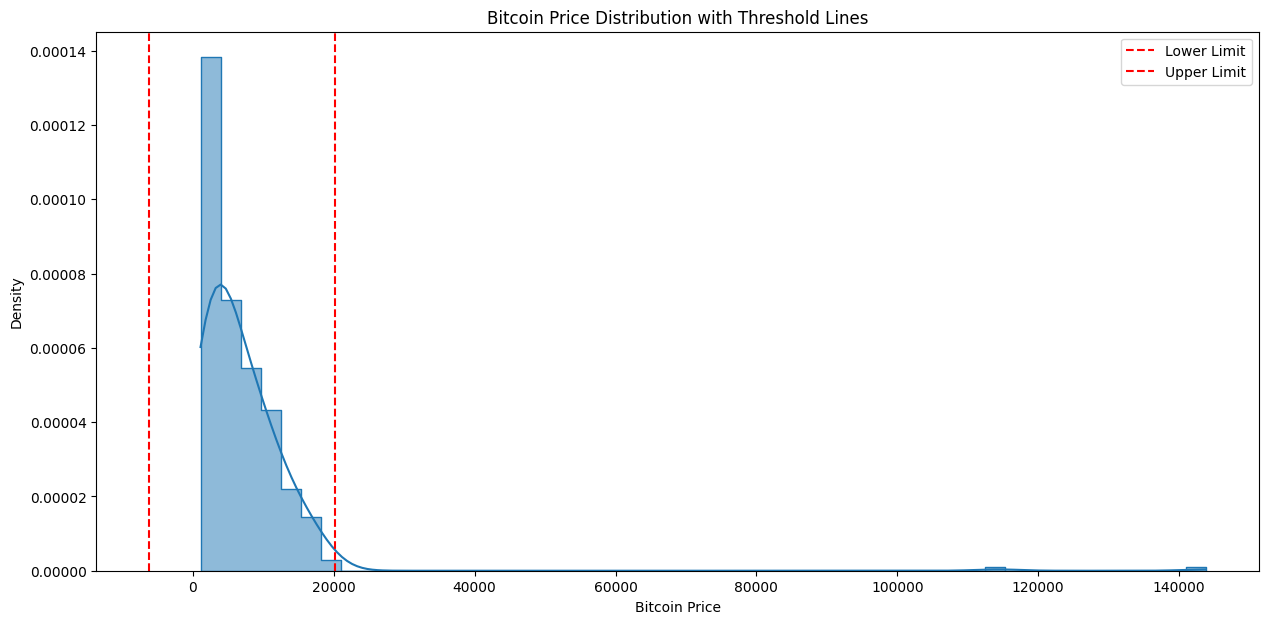

In [234]:
# Create a figure and axis with the specified size
fig, ax = plt.subplots(figsize=(15, 7))

# Plot histogram with KDE for Bitcoin prices
sns.histplot(
    df["Bitcoin"],
    ax=ax,
    bins=50,
    stat="density",
    kde=True,
    element="step",
    fill=True
)

# Draw vertical lines at the lower and upper limits
ax.axvline(lower_limit, color="red", linestyle="--", label="Lower Limit")
ax.axvline(upper_limit, color="red", linestyle="--", label="Upper Limit")

# Add legend and labels
ax.legend()
ax.set_title("Bitcoin Price Distribution with Threshold Lines")
ax.set_xlabel("Bitcoin Price")
ax.set_ylabel("Density")

Our measurement now is a little bit less precise. There are a few valid values (20k) that seem to be above our upper limit. Regardless, it's still a good indicator.

### Cleaning invalid values analytically

It's time now to remove these invalid values analytically, we'll use the upper limit defined by standard deviation:

<Axes: xlabel='Timestamp'>

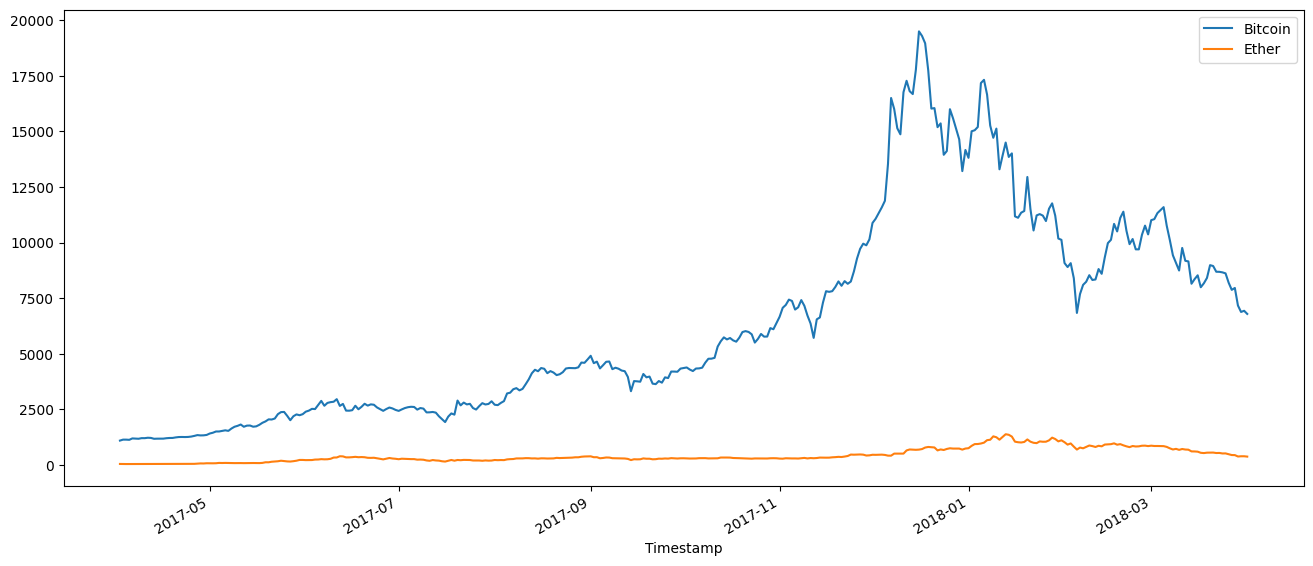

In [236]:
upper_limit = df["Bitcoin"].mean() + 2 * df["Bitcoin"].std()
df[df["Bitcoin"] < upper_limit].plot(figsize=(16, 7))

<Axes: xlabel='Timestamp'>

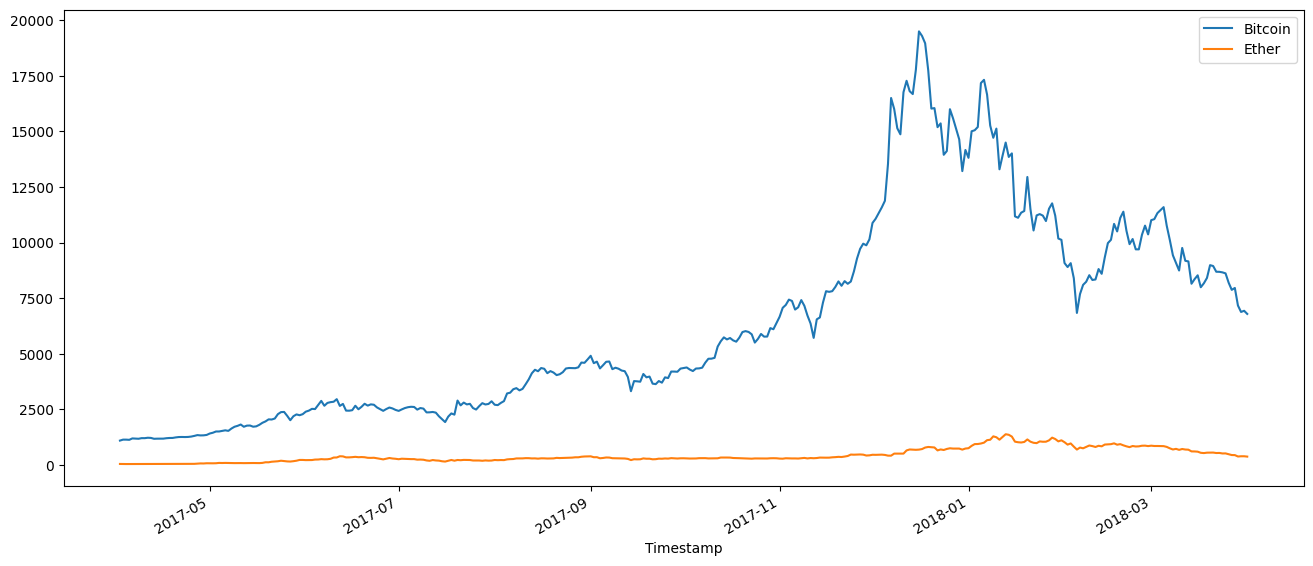

In [237]:
df.drop(df[df["Bitcoin"] > upper_limit].index).plot(figsize=(16, 7))